In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
os.getcwd()

'/home/581/ob1561'

In [3]:
os.chdir("/g/data/jk72/ob1561/JRA_SOTS_PAPA")
os.getcwd()

'/g/data/jk72/ob1561/JRA_SOTS_PAPA'

In [4]:
print("Working directory:", os.getcwd())
print("\nFiles:")
for f in os.listdir("."):
    print(" ", f)

Working directory: /g/data/jk72/ob1561/JRA_SOTS_PAPA

Files:
  pos50n145w_dy (1).cdf
  airt50n145w_dy.cdf
  rh50n145w_dy.cdf
  IMOS_DWM-SOTS_BCMOPSTUW_20230517_SOFS_FV02_SOFS-12-2023-hourly-gridded-product_END-20240406_C-20240629.nc
  Humidity_Wind_JRA.ipynb
  w50n145w_dy.cdf
  wind_10meter_50n145w_hr.cdf
  .ipynb_checkpoints
  sh_2meter_50n145w_hr.cdf


In [5]:
import xarray as xr

w_papa = xr.open_dataset("w50n145w_dy.cdf", decode_times=True)
print(w_papa)
print("\nData variables:")
for v in w_papa.data_vars:
    print(" ", v, "units:", w_papa[v].attrs.get("units"))


<xarray.Dataset> Size: 299kB
Dimensions:   (time: 6797, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 54kB 2007-06-08T12:00:00 ... 2026-01-15T1...
  * depth     (depth) float32 4B -4.0
  * lat       (lat) float32 4B 50.1
  * lon       (lon) float32 4B 215.1
Data variables:
    WU_422    (time, depth, lat, lon) float32 27kB ...
    WV_423    (time, depth, lat, lon) float32 27kB ...
    WS_401    (time, depth, lat, lon) float32 27kB ...
    QWS_5401  (time, depth, lat, lon) float32 27kB ...
    SWS_6401  (time, depth, lat, lon) float32 27kB ...
    SWS_402   (time, depth, lat, lon) float32 27kB ...
    WD_410    (time, depth, lat, lon) float32 27kB ...
    QWD_5410  (time, depth, lat, lon) float32 27kB ...
    SWD_6410  (time, depth, lat, lon) float32 27kB ...
Attributes:
    Data_Source:    OCS Project Office/NOAA/PMEL
    OCS:            Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:      Contact: Dai.C.McClurg@noaa.gov
    missing_value:  1e

In [6]:
rh_papa = xr.open_dataset("rh50n145w_dy.cdf", decode_times=True)
print(rh_papa)
print("\nData variables:")
for v in rh_papa.data_vars:
    print(" ", v, "units:", rh_papa[v].attrs.get("units"))


<xarray.Dataset> Size: 134kB
Dimensions:   (time: 6710, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 54kB 2007-06-08T12:00:00 ... 2025-10-20T1...
  * depth     (depth) float32 4B -2.5
  * lat       (lat) float32 4B 50.1
  * lon       (lon) float32 4B 215.1
Data variables:
    RH_910    (time, depth, lat, lon) float32 27kB ...
    QRH_5910  (time, depth, lat, lon) float32 27kB ...
    SRH_6910  (time, depth, lat, lon) float32 27kB ...
Attributes:
    Data_Source:    OCS Project Office/NOAA/PMEL
    OCS:            Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:      Contact: Dai.C.McClurg@noaa.gov
    missing_value:  1e+35
    _FillValue:     1e+35
    CREATION_DATE:  16:35 15-JAN-2026

Data variables:
  RH_910 units: %
  QRH_5910 units:  
  SRH_6910 units:  


# SOTS 1 year data

In [7]:
sots_1yr = xr.open_dataset("IMOS_DWM-SOTS_BCMOPSTUW_20230517_SOFS_FV02_SOFS-12-2023-hourly-gridded-product_END-20240406_C-20240629.nc", decode_times=True)
print(sots_1yr)
print("\nData variables:")
for v in sots_1yr.data_vars:
    print(" ", v, "units:", sots_1yr[v].attrs.get("units"))

<xarray.Dataset> Size: 16MB
Dimensions:                          (IDX: 39, IDX_AIRT: 2, TIME: 7806,
                                      IDX_ATMP: 2, IDX_CNDC: 10,
                                      IDX_DENSITY: 10, IDX_LW: 2, IDX_PSAL: 10,
                                      IDX_RELH: 2, IDX_SIGMA_T0: 10, IDX_SW: 2,
                                      IDX_TEMP: 35, IDX_UWIND: 2, IDX_VWIND: 2,
                                      IDX_Hm0: 1, IDX_Tz: 1, IDX_BB: 2,
                                      IDX_CPHL: 2, IDX_DOX2: 5, IDX_DOXS: 5,
                                      IDX_PRES: 10, IDX_pHt: 1)
Coordinates: (12/44)
  * IDX_AIRT                         (IDX_AIRT) int32 8B 0 1
  * TIME                             (TIME) datetime64[ns] 62kB 2023-05-17T16...
  * IDX_ATMP                         (IDX_ATMP) int32 8B 0 1
  * IDX_CNDC                         (IDX_CNDC) int32 40B 0 1 4 9 ... 35 36 37
  * IDX_DENSITY                      (IDX_DENSITY) int32 40B 0 1 4 ... 35 36 37

# PAPA Humidity and Windspeed data

In [8]:
ds_wind = xr.open_dataset("wind_10meter_50n145w_hr.cdf", decode_times=True)

print(ds_wind)
print("\nData variables:")
for v in ds_wind.data_vars:
    print(" ", v, "units:", ds_wind[v].attrs.get("units"))

# quick time coverage
print("\nTime span:", ds_wind.time.min().values, "to", ds_wind.time.max().values)

<xarray.Dataset> Size: 4MB
Dimensions:   (time: 161030, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 1MB 2007-06-08T05:00:00 ... 2025-10-20T18...
  * depth     (depth) float32 4B -10.0
  * lat       (lat) float32 4B 50.1
  * lon       (lon) float32 4B 215.1
Data variables:
    UZS_2422  (time, depth, lat, lon) float32 644kB ...
    VZS_2423  (time, depth, lat, lon) float32 644kB ...
    WZS_2401  (time, depth, lat, lon) float32 644kB ...
    DZS_2410  (time, depth, lat, lon) float32 644kB ...
Attributes:
    Data_Source:    OCS Project Office/NOAA/PMEL
    OCS:            Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:      Contact: Dai.C.McClurg@noaa.gov
    missing_value:  1e+35
    _FillValue:     1e+35
    CREATION_DATE:  16:44 19-JAN-2026

Data variables:
  UZS_2422 units: m/s
  VZS_2423 units: m/s
  WZS_2401 units: m/s
  DZS_2410 units: degrees

Time span: 2007-06-08T05:00:00.000000000 to 2025-10-20T18:00:00.000000000


In [9]:
ds_q = xr.open_dataset("sh_2meter_50n145w_hr.cdf", decode_times=True)

print(ds_q)
print("\nData variables:")
for v in ds_q.data_vars:
    print(" ", v, "units:", ds_q[v].attrs.get("units"))

print("\nTime span:", ds_q.time.min().values, "to", ds_q.time.max().values)

# sanity check of q range (typical order ~0.001–0.020 kg/kg)
qvar = list(ds_q.data_vars)[0]
print("q min/max:", float(ds_q[qvar].min()), float(ds_q[qvar].max()))

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 161030, depth: 1, lat: 1, lon: 1)
Coordinates:
  * time      (time) datetime64[ns] 1MB 2007-06-08T05:00:00 ... 2025-10-20T18...
  * depth     (depth) float32 4B -2.0
  * lat       (lat) float32 4B 50.0
  * lon       (lon) float32 4B 215.0
Data variables:
    QZS_2513  (time, depth, lat, lon) float32 644kB ...
Attributes:
    platform_code:                50n145w
    site_code:                    50n145w
    array:                        TAO/TRITON
    Request_for_acknowledgement:  If you use these data in publications or pr...
    Data_Source:                  OCS Project Office/NOAA/PMEL
    OCS:                          Dr. Meghan F. Cronin: Meghan.F.Cronin@noaa.gov
    File_info:                    Contact: Dai.C.McClurg@noaa.gov
    missing_value:                1e+35
    _FillValue:                   1e+35
    CREATION_DATE:                16:44 19-JAN-2026

Data variables:
  QZS_2513 units: g/kg

Time span: 2007-06-08T05:00:00.00000

### papa windspeed and q computation

In [10]:
# Load PAPA computed-flux products
ds_papa_w = xr.open_dataset("wind_10meter_50n145w_hr.cdf", decode_times=True)
ds_papa_q = xr.open_dataset("sh_2meter_50n145w_hr.cdf", decode_times=True)

print("PAPA wind vars:", list(ds_papa_w.data_vars))
print("PAPA q vars:", list(ds_papa_q.data_vars))

# Confirm time coverage
print("Wind TIME start/end:", ds_papa_w.time.values[0], "to", ds_papa_w.time.values[-1])
print("q TIME start/end:", ds_papa_q.time.values[0], "to", ds_papa_q.time.values[-1])

# Units check
for v in ds_papa_w.data_vars:
    print("Wind", v, "units:", ds_papa_w[v].attrs.get("units"))
for v in ds_papa_q.data_vars:
    print("q", v, "units:", ds_papa_q[v].attrs.get("units"))

PAPA wind vars: ['UZS_2422', 'VZS_2423', 'WZS_2401', 'DZS_2410']
PAPA q vars: ['QZS_2513']
Wind TIME start/end: 2007-06-08T05:00:00.000000000 to 2025-10-20T18:00:00.000000000
q TIME start/end: 2007-06-08T05:00:00.000000000 to 2025-10-20T18:00:00.000000000
Wind UZS_2422 units: m/s
Wind VZS_2423 units: m/s
Wind WZS_2401 units: m/s
Wind DZS_2410 units: degrees
q QZS_2513 units: g/kg


In [11]:

# Extract variables
wspd_papa = ds_papa_w["WZS_2401"]            # 10 m wind speed (m/s)
q_papa = ds_papa_q["QZS_2513"] / 1000.0      # g/kg -> kg/kg

# Mask fill values (OCS convention)
wspd_papa = wspd_papa.where(wspd_papa < 1e34)
q_papa = q_papa.where(q_papa < 1e34)

# Monthly means (month start)
wspd_papa_mon = wspd_papa.resample(time="MS").mean(skipna=True)
q_papa_mon = q_papa.resample(time="MS").mean(skipna=True)

# Diagnostics
print("PAPA monthly points (wind):", wspd_papa_mon.sizes["time"])
print("PAPA monthly points (q):", q_papa_mon.sizes["time"])

print("PAPA monthly TIME start/end (wind):",
      wspd_papa_mon["time"].values[0], "to", wspd_papa_mon["time"].values[-1])
print("PAPA monthly TIME start/end (q):",
      q_papa_mon["time"].values[0], "to", q_papa_mon["time"].values[-1])

print("PAPA monthly wind min/max (m/s):",
      float(wspd_papa_mon.min()), float(wspd_papa_mon.max()))
print("PAPA monthly q min/max (kg/kg):",
      float(q_papa_mon.min()), float(q_papa_mon.max()))


PAPA monthly points (wind): 221
PAPA monthly points (q): 221
PAPA monthly TIME start/end (wind): 2007-06-01T00:00:00.000000000 to 2025-10-01T00:00:00.000000000
PAPA monthly TIME start/end (q): 2007-06-01T00:00:00.000000000 to 2025-10-01T00:00:00.000000000
PAPA monthly wind min/max (m/s): 5.244339942932129 12.345430374145508
PAPA monthly q min/max (kg/kg): 0.004204593598842621 1.0000002266094847e+32


In [12]:
# Re-extract to be safe
q_papa = ds_papa_q["QZS_2513"]

# Mask known fill values (OCS uses ~1e32)
q_papa = q_papa.where(q_papa < 1e20)

# Convert g/kg -> kg/kg
q_papa = q_papa / 1000.0

# Monthly means
q_papa_mon = q_papa.resample(time="MS").mean(skipna=True)

# Diagnostics
print("PAPA monthly q min/max (kg/kg):",
      float(q_papa_mon.min()), float(q_papa_mon.max()))

print("Number of valid months:",
      int((q_papa_mon < 1e20).sum()))

PAPA monthly q min/max (kg/kg): 0.004052163567394018 0.010128780268132687
Number of valid months: 192


# Rest of SOTS data

In [13]:
SOTS_DIR = "/g/data/jk72/ob1561/SOTS_hourly_gridded"

files = sorted(glob.glob(os.path.join(SOTS_DIR, "*hourly-gridded-product*.nc")))
print("Found hourly-gridded-product files:", len(files))

# Print just filenames (not full paths)
for f in files:
    print(os.path.basename(f))

Found hourly-gridded-product files: 19
IMOS_DWM-SOTS_BCFGMOPSTUW_20200901_SOFS_FV02_SOFS-9-2020-hourly-gridded-product_END-20210423_C-20221117.nc
IMOS_DWM-SOTS_BCFGMOPSTU_20190318_SOFS_FV02_SOFS-8-2019-hourly-gridded-product_END-20200904_C-20221117.nc
IMOS_DWM-SOTS_BCFMOPSTU_20100318_SOFS_FV02_SOFS-1-2010-hourly-gridded-product_END-20110420_C-20241018.nc
IMOS_DWM-SOTS_BCFMOPSTU_20111125_SOFS_FV02_SOFS-2-2011-hourly-gridded-product_END-20120722_C-20241018.nc
IMOS_DWM-SOTS_BCFMOPSTU_20160316_Pulse_FV02_FluxPulse-1-2016-hourly-gridded-product_END-20160623_C-20241107.nc
IMOS_DWM-SOTS_BCFMOPST_20180822_SOFS_FV02_SOFS-7.5-2018-hourly-gridded-product_END-20190322_C-20241107.nc
IMOS_DWM-SOTS_BCFOPSTU_20090928_Pulse_FV02_Pulse-6-2009-hourly-gridded-product_END-20100318_C-20241018.nc
IMOS_DWM-SOTS_BCFOPSTU_20100912_Pulse_FV02_Pulse-7-2010-hourly-gridded-product_END-20110417_C-20241027.nc
IMOS_DWM-SOTS_BCFOPSTU_20110804_Pulse_FV02_Pulse-8-2011-hourly-gridded-product_END-20120719_C-20241101.nc
IMO

In [14]:
# verify uwind and q components

needed = {"UWIND", "VWIND", "RELH", "ATMP", "PRES"}

for f in files:
    ds = xr.open_dataset(f)
    present = needed.intersection(ds.data_vars)
    missing = needed - present
    print(os.path.basename(f))
    print("  present:", sorted(present))
    print("  missing:", sorted(missing))
    ds.close()


IMOS_DWM-SOTS_BCFGMOPSTUW_20200901_SOFS_FV02_SOFS-9-2020-hourly-gridded-product_END-20210423_C-20221117.nc
  present: ['ATMP', 'PRES', 'RELH', 'UWIND', 'VWIND']
  missing: []
IMOS_DWM-SOTS_BCFGMOPSTU_20190318_SOFS_FV02_SOFS-8-2019-hourly-gridded-product_END-20200904_C-20221117.nc
  present: ['ATMP', 'PRES', 'RELH', 'UWIND', 'VWIND']
  missing: []
IMOS_DWM-SOTS_BCFMOPSTU_20100318_SOFS_FV02_SOFS-1-2010-hourly-gridded-product_END-20110420_C-20241018.nc
  present: ['ATMP', 'PRES', 'RELH', 'UWIND', 'VWIND']
  missing: []
IMOS_DWM-SOTS_BCFMOPSTU_20111125_SOFS_FV02_SOFS-2-2011-hourly-gridded-product_END-20120722_C-20241018.nc
  present: ['ATMP', 'PRES', 'RELH', 'UWIND', 'VWIND']
  missing: []
IMOS_DWM-SOTS_BCFMOPSTU_20160316_Pulse_FV02_FluxPulse-1-2016-hourly-gridded-product_END-20160623_C-20241107.nc
  present: ['ATMP', 'PRES', 'RELH', 'UWIND', 'VWIND']
  missing: []
IMOS_DWM-SOTS_BCFMOPST_20180822_SOFS_FV02_SOFS-7.5-2018-hourly-gridded-product_END-20190322_C-20241107.nc
  present: ['ATMP', 

In [15]:
needed = {"UWIND", "VWIND", "RELH", "ATMP", "PRES"}

good_files = []
bad_files = []

for f in files:  # uses your existing 'files' list
    ds = xr.open_dataset(f)
    present = set(ds.data_vars)
    missing = needed - present
    ds.close()

    if len(missing) == 0:
        good_files.append(f)
    else:
        bad_files.append((os.path.basename(f), sorted(list(missing))))

print("Good files:", len(good_files))
print("Bad files:", len(bad_files))

print("\nBad files (missing vars):")
for name, miss in bad_files:
    print(" ", name, "missing:", miss)

Good files: 11
Bad files: 8

Bad files (missing vars):
  IMOS_DWM-SOTS_BCFOPSTU_20090928_Pulse_FV02_Pulse-6-2009-hourly-gridded-product_END-20100318_C-20241018.nc missing: ['ATMP', 'RELH', 'UWIND', 'VWIND']
  IMOS_DWM-SOTS_BCFOPSTU_20100912_Pulse_FV02_Pulse-7-2010-hourly-gridded-product_END-20110417_C-20241027.nc missing: ['ATMP', 'RELH', 'UWIND', 'VWIND']
  IMOS_DWM-SOTS_BCFOPSTU_20110804_Pulse_FV02_Pulse-8-2011-hourly-gridded-product_END-20120719_C-20241101.nc missing: ['ATMP', 'RELH', 'UWIND', 'VWIND']
  IMOS_DWM-SOTS_BCFOPSTU_20120717_Pulse_FV02_Pulse-9-2012-hourly-gridded-product_END-20130505_C-20241107.nc missing: ['ATMP', 'RELH', 'UWIND', 'VWIND']
  IMOS_DWM-SOTS_BCFOPSTU_20130507_Pulse_FV02_Pulse-10-2013-hourly-gridded-product_END-20131013_C-20241107.nc missing: ['ATMP', 'RELH', 'UWIND', 'VWIND']
  IMOS_DWM-SOTS_BCFOPSTU_20150325_Pulse_FV02_Pulse-11-2015-hourly-gridded-product_END-20160319_C-20241107.nc missing: ['ATMP', 'RELH', 'UWIND', 'VWIND']
  IMOS_DWM-SOTS_BCOPSTUW_202104

In [16]:
test = xr.open_dataset(good_files[0])

print("ATMP units:", test["ATMP"].attrs.get("units"))
print("PRES units:", test["PRES"].attrs.get("units"))
print("UWIND units:", test["UWIND"].attrs.get("units"))
print("RELH units:", test["RELH"].attrs.get("units"))

test.close()


ATMP units: hectopascal
PRES units: dbar
UWIND units: m/s
RELH units: percent


In [17]:
# build SOTS wind speed and specific humidity
def preprocess(ds):
    return ds[["UWIND", "VWIND", "RELH", "ATMP"]]

ds_sots = xr.open_mfdataset(
    good_files,
    combine="nested",
    concat_dim="TIME",
    preprocess=preprocess,
    coords="minimal",
    data_vars="minimal",
    compat="override"
).sortby("TIME")

# Mask fill values
UW = ds_sots["UWIND"].where(ds_sots["UWIND"] < 1e34)
VW = ds_sots["VWIND"].where(ds_sots["VWIND"] < 1e34)
RH = ds_sots["RELH"].where(ds_sots["RELH"] < 1e34) / 100.0  # fraction
p_hPa = ds_sots["ATMP"].where(ds_sots["ATMP"] < 1e34)        # hPa

# Wind speed at SOTS
wspd_sots = np.sqrt(UW**2 + VW**2)

# Convert RH + T (°C) + p (hPa) -> specific humidity q (kg/kg)
# We need air temperature; in these files it is often "AIRT". Check first:
print("Has AIRT?", "AIRT" in xr.open_dataset(good_files[0]).variables)

/jobfs/159628489.gadi-pbs/ipykernel_1071513/2232494738.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'IDX_ATMP' ('IDX_ATMP',) The recommendation is to set join explicitly for this case.
  ds_sots = xr.open_mfdataset(
/jobfs/159628489.gadi-pbs/ipykernel_1071513/2232494738.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'IDX_RELH' ('IDX_RELH',) The recommendation is to set join explicitly for this case.
  ds_sots = xr.open_mfdataset(
/jobfs/159628489.gadi-pbs/ipykernel_1071513/2232494738.py:5: FutureWarni

Has AIRT? True


In [18]:
test = xr.open_dataset(good_files[0])
cand = [v for v in ["AIRT", "Tz", "AT", "TAIR", "TEMP_AIR"] if v in test.variables]
print("Candidate air-temperature vars present:", cand)
for v in cand:
    print(v, "units:", test[v].attrs.get("units"))
test.close()

Candidate air-temperature vars present: ['AIRT', 'Tz']
AIRT units: celsius
Tz units: s


In [19]:
import xarray as xr

def preprocess(ds):
    return ds[["UWIND", "VWIND", "RELH", "ATMP", "AIRT"]]

ds_sots = xr.open_mfdataset(
    good_files,
    combine="nested",
    concat_dim="TIME",
    preprocess=preprocess,
    coords="minimal",
    data_vars="minimal",
    compat="override"
).sortby("TIME")

print("Variables in ds_sots:", list(ds_sots.data_vars))

/jobfs/159628489.gadi-pbs/ipykernel_1071513/4077171263.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'IDX_AIRT' ('IDX_AIRT',) The recommendation is to set join explicitly for this case.
  ds_sots = xr.open_mfdataset(
/jobfs/159628489.gadi-pbs/ipykernel_1071513/4077171263.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'IDX_ATMP' ('IDX_ATMP',) The recommendation is to set join explicitly for this case.
  ds_sots = xr.open_mfdataset(
/jobfs/159628489.gadi-pbs/ipykernel_1071513/4077171263.py:6: FutureWarni

Variables in ds_sots: ['UWIND', 'VWIND', 'RELH', 'ATMP', 'AIRT']


### Compute SOTS wind speed min/max

In [20]:
# Mask fill values
UW = ds_sots["UWIND"].where(ds_sots["UWIND"] < 1e34)
VW = ds_sots["VWIND"].where(ds_sots["VWIND"] < 1e34)

# Wind speed (m/s)
wspd_sots = np.sqrt(UW**2 + VW**2)

print("SOTS wind speed min/max (m/s):",
      float(wspd_sots.min()), float(wspd_sots.max()))

SOTS wind speed min/max (m/s): 0.0 18.26572608947754


### Convert SOTS RH to q (kg/kg)

In [21]:
# Mask fill values
RH = ds_sots["RELH"].where(ds_sots["RELH"] < 1e34) / 100.0   # fraction (0–1)
T_air = ds_sots["AIRT"].where(ds_sots["AIRT"] < 1e34)        # °C
p_hPa = ds_sots["ATMP"].where(ds_sots["ATMP"] < 1e34)        # hPa

# Saturation vapour pressure (hPa) using Tetens formula
e_s = 6.112 * np.exp((17.67 * T_air) / (T_air + 243.5))

# Actual vapour pressure (hPa)
e = RH * e_s

# Specific humidity q (kg/kg)
q_sots = 0.622 * e / (p_hPa - 0.378 * e)

print("SOTS q min/max (kg/kg):", float(q_sots.min()), float(q_sots.max()))


SOTS q min/max (kg/kg): -0.06747209280729294 0.06101163849234581


In [22]:
RH_pct = ds_sots["RELH"].where(ds_sots["RELH"] < 1e34)  # %
T_air = ds_sots["AIRT"].where(ds_sots["AIRT"] < 1e34)   # °C
p_hPa  = ds_sots["ATMP"].where(ds_sots["ATMP"] < 1e34)  # hPa

# Physical bounds (conservative, suitable for met QC)
RH_pct = RH_pct.where((RH_pct >= 0) & (RH_pct <= 100))
T_air  = T_air.where((T_air > -50) & (T_air < 50))
p_hPa  = p_hPa.where((p_hPa > 800) & (p_hPa < 1100))

RH = RH_pct / 100.0

e_s = 6.112 * np.exp((17.67 * T_air) / (T_air + 243.5))
e = RH * e_s
q_sots = 0.622 * e / (p_hPa - 0.378 * e)

print("SOTS q min/max (kg/kg):", float(q_sots.min()), float(q_sots.max()))
print("Fraction valid:", float(np.isfinite(q_sots).mean()))

SOTS q min/max (kg/kg): 0.0 0.05998995527625084
Fraction valid: 0.015470117616991574


## Monthly averaging for SOTS

In [23]:
# --- STEP 1: Monthly means for SOTS wind speed and specific humidity ---
# NOTE: TIME is already decoded; do NOT use xr.decode_cf here

# Monthly means (NaNs skipped automatically)
wspd_sots_mon = wspd_sots.resample(TIME="MS").mean(skipna=True)
q_sots_mon    = q_sots.resample(TIME="MS").mean(skipna=True)

print("Monthly wind speed shape:", wspd_sots_mon.shape)
print("Monthly q shape:", q_sots_mon.shape)

# Sanity checks
print("SOTS monthly wind min/max (m/s):",
      float(wspd_sots_mon.min()), float(wspd_sots_mon.max()))

print("SOTS monthly q min/max (kg/kg):",
      float(q_sots_mon.min()), float(q_sots_mon.max()))


Monthly wind speed shape: (8, 170, 8)
Monthly q shape: (8, 170, 9, 8)
SOTS monthly wind min/max (m/s): 0.0 10.28175163269043
SOTS monthly q min/max (kg/kg): 1.873302971944213e-05 0.051244404166936874


In [24]:
print("good_files count:", len(good_files))
print("TIME length (hourly points):", ds_sots.sizes["TIME"])
print("TIME start:", ds_sots["TIME"].values[0])
print("TIME end:  ", ds_sots["TIME"].values[-1])


good_files count: 11
TIME length (hourly points): 71952
TIME start: 2010-03-18T01:00:00.000000000
TIME end:   2024-04-06T21:00:00.000000000


In [25]:
# Collapse each variable over its instrument index dimension (IDX_*)
UW_1d = UW.mean(dim=[d for d in UW.dims if d.startswith("IDX_")], skipna=True)
VW_1d = VW.mean(dim=[d for d in VW.dims if d.startswith("IDX_")], skipna=True)

# Wind speed (1-D over TIME)
wspd_sots_1d = np.sqrt(UW_1d**2 + VW_1d**2)

# For q_sots, collapse over its IDX_* dims as well
q_sots_1d = q_sots.mean(dim=[d for d in q_sots.dims if d.startswith("IDX_")], skipna=True)

print("wspd_sots_1d dims:", wspd_sots_1d.dims, "shape:", wspd_sots_1d.shape)
print("q_sots_1d dims:", q_sots_1d.dims, "shape:", q_sots_1d.shape)
print("TIME start/end:", wspd_sots_1d["TIME"].values[0], "to", wspd_sots_1d["TIME"].values[-1])

wspd_sots_1d dims: ('TIME',) shape: (71952,)
q_sots_1d dims: ('TIME',) shape: (71952,)
TIME start/end: 2010-03-18T01:00:00.000000000 to 2024-04-06T21:00:00.000000000


In [26]:
# Monthly means (month start)
wspd_sots_mon = wspd_sots_1d.resample(TIME="MS").mean(skipna=True)
q_sots_mon    = q_sots_1d.resample(TIME="MS").mean(skipna=True)

print("Monthly points (wspd):", wspd_sots_mon.sizes["TIME"])
print("Monthly points (q):", q_sots_mon.sizes["TIME"])

print("Monthly TIME start/end (wspd):", wspd_sots_mon["TIME"].values[0], "to", wspd_sots_mon["TIME"].values[-1])
print("Monthly TIME start/end (q):", q_sots_mon["TIME"].values[0], "to", q_sots_mon["TIME"].values[-1])

print("SOTS monthly wind min/max (m/s):", float(wspd_sots_mon.min()), float(wspd_sots_mon.max()))
print("SOTS monthly q min/max (kg/kg):", float(q_sots_mon.min()), float(q_sots_mon.max()))

Monthly points (wspd): 170
Monthly points (q): 170
Monthly TIME start/end (wspd): 2010-03-01T00:00:00.000000000 to 2024-04-01T00:00:00.000000000
Monthly TIME start/end (q): 2010-03-01T00:00:00.000000000 to 2024-04-01T00:00:00.000000000
SOTS monthly wind min/max (m/s): 0.7468767762184143 10.01235294342041
SOTS monthly q min/max (kg/kg): 0.003091368591412902 0.028541529551148415


# JRA Data

In [27]:
base = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hr"

print("Base exists:", os.path.isdir(base))
print("\n3hr variable folders (first 40):")
vars_ = sorted([d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))])
print(vars_[:40])
print("\nTotal folders:", len(vars_))


Base exists: True

3hr variable folders (first 40):
['prra', 'prsn', 'rlds', 'rsds']

Total folders: 4


In [28]:
root = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos"
print("Subfolders under atmos:")
print(sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]))

Subfolders under atmos:
['3hr', '3hrPt', 'fx']


In [29]:
base_3hrPt = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt"

vars_3hrPt = sorted([d for d in os.listdir(base_3hrPt) if os.path.isdir(os.path.join(base_3hrPt, d))])

print("3hrPt variable folders (first 60):")
print(vars_3hrPt[:60])
print("\nTotal folders:", len(vars_3hrPt))

3hrPt variable folders (first 60):
['huss', 'psl', 'tas', 'ts', 'uas', 'vas']

Total folders: 6


In [30]:
base = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt"

def inspect(var):
    vdir = os.path.join(base, var, "gr", "v20190429")
    flist = sorted(glob.glob(os.path.join(vdir, "*.nc")))
    print(f"\n{var}: files found =", len(flist))
    print("First file:", os.path.basename(flist[0]))

    ds = xr.open_dataset(flist[0])
    print(ds)

    # Print variable units
    for v in ds.data_vars:
        print(" ", v, "units:", ds[v].attrs.get("units"))
    ds.close()

inspect("uas")
inspect("vas")
inspect("huss")


uas: files found = 62
First file: uas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010000-195812312100.nc
<xarray.Dataset> Size: 2GB
Dimensions:    (time: 2920, bnds: 2, lat: 320, lon: 640)
Coordinates:
  * time       (time) datetime64[ns] 23kB 1958-01-01 ... 1958-12-31T21:00:00
  * lat        (lat) float64 3kB -89.57 -89.01 -88.45 ... 88.45 89.01 89.57
  * lon        (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 47kB ...
    lat_bnds   (lat, bnds) float64 5kB ...
    lon_bnds   (lon, bnds) float64 10kB ...
    uas        (time, lat, lon) float32 2GB ...
Attributes: (12/36)
    Conventions:         CF-1.7 CMIP-6.2
    activity_id:         input4MIPs
    cell_measures:       area: areacella
    comment:             Based on JRA-55 reanalysis (1958-01 to 2019-01)
    contact:             Hiroyuki Tsujino (htsujino@mri-jma.go.jp)
 

In [31]:
base = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt"
vars_need = ["uas", "vas", "huss"]

for var in vars_need:
    vdir = os.path.join(base, var, "gr", "v20190429")
    flist = sorted(glob.glob(os.path.join(vdir, "*.nc")))
    print("\n", var)
    print(" directory:", vdir)
    print(" files:", len(flist))
    if flist:
        print(" first:", os.path.basename(flist[0]))
        print(" last :", os.path.basename(flist[-1]))


 uas
 directory: /g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt/uas/gr/v20190429
 files: 62
 first: uas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010000-195812312100.nc
 last : uas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_201901010000-201901052100.nc

 vas
 directory: /g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt/vas/gr/v20190429
 files: 62
 first: vas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010000-195812312100.nc
 last : vas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_201901010000-201901052100.nc

 huss
 directory: /g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt/huss/gr/v20190429
 files: 62
 first: huss_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010000-195812312100.nc
 last : huss_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_201901010000-201901052100.nc


In [32]:
JRA_BASE = "/g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt"

uas_files  = sorted(glob.glob(f"{JRA_BASE}/uas/gr/v20190429/*.nc"))
vas_files  = sorted(glob.glob(f"{JRA_BASE}/vas/gr/v20190429/*.nc"))
huss_files = sorted(glob.glob(f"{JRA_BASE}/huss/gr/v20190429/*.nc"))

print("uas files:", len(uas_files))
print("vas files:", len(vas_files))
print("huss files:", len(huss_files))
print("First uas:", uas_files[0])
print("First huss:", huss_files[0])

uas files: 62
vas files: 62
huss files: 62
First uas: /g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt/uas/gr/v20190429/uas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010000-195812312100.nc
First huss: /g/data/qv56/replicas/input4MIPs/CMIP6/OMIP/MRI/MRI-JRA55-do-1-4-0/atmos/3hrPt/huss/gr/v20190429/huss_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-4-0_gr_195801010000-195812312100.nc


In [33]:
ds_uas = xr.open_mfdataset(
    uas_files,
    combine="by_coords",
    coords="minimal",
    data_vars="minimal"
)

ds_vas = xr.open_mfdataset(
    vas_files,
    combine="by_coords",
    coords="minimal",
    data_vars="minimal"
)

ds_huss = xr.open_mfdataset(
    huss_files,
    combine="by_coords",
    coords="minimal",
    data_vars="minimal"
)

print(ds_uas)
print(ds_huss)


/jobfs/159628489.gadi-pbs/ipykernel_1071513/2278533210.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_uas = xr.open_mfdataset(
/jobfs/159628489.gadi-pbs/ipykernel_1071513/2278533210.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_uas = xr.open_mfdataset(
/jobfs/159628489.gadi-pbs/ipykernel_1071513/2278533210.py:1: Futur

<xarray.Dataset> Size: 146GB
Dimensions:    (time: 178280, bnds: 2, lat: 320, lon: 640)
Coordinates:
  * time       (time) datetime64[ns] 1MB 1958-01-01 ... 2019-01-05T21:00:00
  * lat        (lat) float64 3kB -89.57 -89.01 -88.45 ... 88.45 89.01 89.57
  * lon        (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
    height     float64 8B 10.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 3MB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 5kB dask.array<chunksize=(320, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 10kB dask.array<chunksize=(640, 2), meta=np.ndarray>
    uas        (time, lat, lon) float32 146GB dask.array<chunksize=(1, 320, 640), meta=np.ndarray>
Attributes: (12/36)
    Conventions:         CF-1.7 CMIP-6.2
    activity_id:         input4MIPs
    cell_measures:       area: areacella
    comment:             Based on JRA-55 reanalysis (1958-01 to 2019-01)
    con

In [34]:
u10 = ds_uas["uas"]
v10 = ds_vas["vas"]
q_jra = ds_huss["huss"]

# Wind speed
wspd_jra = np.sqrt(u10**2 + v10**2)

print("Wind speed units:", wspd_jra.attrs.get("units"))
print("q units:", q_jra.attrs.get("units"))

print("TIME range:", wspd_jra.time.min().values, "to", wspd_jra.time.max().values)


Wind speed units: None
q units: 1
TIME range: 1958-01-01T00:00:00.000000000 to 2019-01-05T21:00:00.000000000


In [35]:
start = "2010-03-01"
end   = "2024-04-01"

wspd_jra_sel = wspd_jra.sel(time=slice(start, end))
q_jra_sel    = q_jra.sel(time=slice(start, end))

print("Restricted TIME:",
      wspd_jra_sel.time.min().values,
      "to",
      wspd_jra_sel.time.max().values)


Restricted TIME: 2010-03-01T00:00:00.000000000 to 2019-01-05T21:00:00.000000000


In [36]:
print("wspd_papa_o:", wspd_papa_o.dims, wspd_papa_o.shape)
print("wspd_papa_o squeezed:", wspd_papa_o.squeeze(drop=True).dims, wspd_papa_o.squeeze(drop=True).shape)

NameError: name 'wspd_papa_o' is not defined

In [37]:
# Count valid hourly q values per month
q_count = q_sots_1d.resample(TIME="MS").count()

# Monthly mean q (you already have this, but recompute cleanly)
q_sots_mon = q_sots_1d.resample(TIME="MS").mean(skipna=True)

# Require at least N valid hourly points per month (e.g. 200 hours ~ 8 days)
N = 200
q_sots_mon_qc = q_sots_mon.where(q_count >= N)

print("Months kept:", int((q_count >= N).sum()), "out of", q_count.size)
print("q max after QC:", float(q_sots_mon_qc.max()))

Months kept: 96 out of 170
q max after QC: 0.028541529551148415


Aligned overlap: 2010-03-01T00:00:00.000000000 to 2019-01-01T00:00:00.000000000
Months in overlap: 107


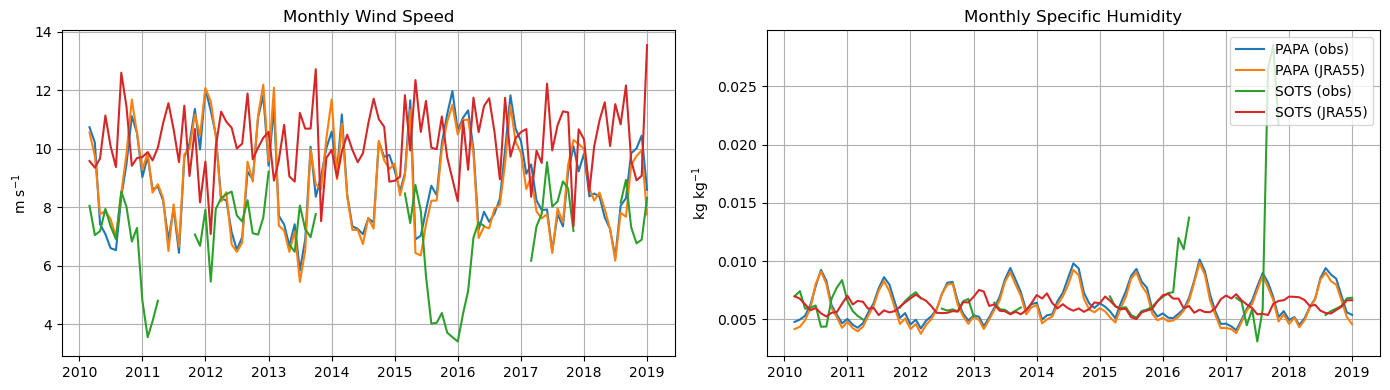

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# ----------------------------
# 1) Extract JRA at SOTS and PAPA and make monthly means
# ----------------------------
# Coordinates
lat_sots, lon_sots = -47.0, 142.0
lat_papa, lon_papa = 50.1, 215.1   # 144.9W = 215.1E (0–360)

# Nearest-gridpoint extraction
wspd_jra_sots = wspd_jra.sel(lat=lat_sots, lon=lon_sots, method="nearest")
q_jra_sots    = q_jra.sel(lat=lat_sots, lon=lon_sots, method="nearest")

wspd_jra_papa = wspd_jra.sel(lat=lat_papa, lon=lon_papa, method="nearest")
q_jra_papa    = q_jra.sel(lat=lat_papa, lon=lon_papa, method="nearest")

# Monthly means (month-start)
wspd_jra_sots_mon = wspd_jra_sots.resample(time="MS").mean(skipna=True)
q_jra_sots_mon    = q_jra_sots.resample(time="MS").mean(skipna=True)

wspd_jra_papa_mon = wspd_jra_papa.resample(time="MS").mean(skipna=True)
q_jra_papa_mon    = q_jra_papa.resample(time="MS").mean(skipna=True)

# Add units for derived wind speed (optional)
wspd_jra_sots_mon.attrs["units"] = "m s-1"
wspd_jra_papa_mon.attrs["units"] = "m s-1"

# ----------------------------
# 2) Align to a common monthly time window across all 8 series
# ----------------------------
# Convert PAPA time coord name to TIME to match SOTS (clean alignment)
wspd_papa_mon2 = wspd_papa_mon.rename({"time": "TIME"})
q_papa_mon2    = q_papa_mon.rename({"time": "TIME"})

wspd_jra_sots_mon2 = wspd_jra_sots_mon.rename({"time": "TIME"})
q_jra_sots_mon2    = q_jra_sots_mon.rename({"time": "TIME"})
wspd_jra_papa_mon2 = wspd_jra_papa_mon.rename({"time": "TIME"})
q_jra_papa_mon2    = q_jra_papa_mon.rename({"time": "TIME"})

# Common overlap bounds
t0 = max(
    wspd_sots_mon.TIME.values[0],
    q_sots_mon.TIME.values[0],
    wspd_papa_mon2.TIME.values[0],
    q_papa_mon2.TIME.values[0],
    wspd_jra_sots_mon2.TIME.values[0],
    q_jra_sots_mon2.TIME.values[0],
    wspd_jra_papa_mon2.TIME.values[0],
    q_jra_papa_mon2.TIME.values[0],
)
t1 = min(
    wspd_sots_mon.TIME.values[-1],
    q_sots_mon.TIME.values[-1],
    wspd_papa_mon2.TIME.values[-1],
    q_papa_mon2.TIME.values[-1],
    wspd_jra_sots_mon2.TIME.values[-1],
    q_jra_sots_mon2.TIME.values[-1],
    wspd_jra_papa_mon2.TIME.values[-1],
    q_jra_papa_mon2.TIME.values[-1],
)

# Slice all series to overlap window
wspd_sots_o = wspd_sots_mon.sel(TIME=slice(t0, t1))
q_sots_o    = q_sots_mon.sel(TIME=slice(t0, t1))

wspd_papa_o = wspd_papa_mon2.sel(TIME=slice(t0, t1))
q_papa_o    = q_papa_mon2.sel(TIME=slice(t0, t1))

wspd_jra_sots_o = wspd_jra_sots_mon2.sel(TIME=slice(t0, t1))
q_jra_sots_o    = q_jra_sots_mon2.sel(TIME=slice(t0, t1))

wspd_jra_papa_o = wspd_jra_papa_mon2.sel(TIME=slice(t0, t1))
q_jra_papa_o    = q_jra_papa_mon2.sel(TIME=slice(t0, t1))

print("Aligned overlap:", str(t0), "to", str(t1))
print("Months in overlap:", wspd_sots_o.sizes["TIME"])

# ----------------------------
# 3) Plot: 2 panels (windspeed, specific humidity)
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

# Panel A: Wind speed
ax = axes[0]
ax.plot(wspd_papa_o.TIME.values, wspd_papa_o.squeeze(drop=True).values, label="PAPA (obs)")
ax.plot(wspd_jra_papa_o.TIME.values, wspd_jra_papa_o.squeeze(drop=True).values, label="PAPA (JRA55)")
ax.plot(wspd_sots_o.TIME.values, wspd_sots_o.squeeze(drop=True).values, label="SOTS (obs)")
ax.plot(wspd_jra_sots_o.TIME.values, wspd_jra_sots_o.squeeze(drop=True).values, label="SOTS (JRA55)")

ax.set_title("Monthly Wind Speed")
ax.set_ylabel("m s$^{-1}$")
ax.grid(True)

# Panel B: Specific humidity
ax = axes[1]
ax.plot(q_papa_o.TIME.values, q_papa_o.squeeze(drop=True).values, label="PAPA (obs)")
ax.plot(q_jra_papa_o.TIME.values, q_jra_papa_o.squeeze(drop=True).values, label="PAPA (JRA55)")
ax.plot(q_sots_o.TIME.values, q_sots_o.squeeze(drop=True).values, label="SOTS (obs)")
ax.plot(q_jra_sots_o.TIME.values, q_jra_sots_o.squeeze(drop=True).values, label="SOTS (JRA55)")
ax.set_title("Monthly Specific Humidity")
ax.set_ylabel("kg kg$^{-1}$")
ax.grid(True)

# Shared legend
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()
